In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Get the Data 

In [2]:
cclass = pd.read_csv(r'Data\cclass.csv')
bmw = pd.read_csv(r'Data\bmw.csv')
merc = pd.read_csv(r'Data\merc.csv')
hyundi = pd.read_csv(r'Data\hyundi.csv')
focus = pd.read_csv(r'Data\focus.csv')
vauxhall = pd.read_csv(r'Data\vauxhall.csv')
vw = pd.read_csv(r'Data\vw.csv')
audi = pd.read_csv(r'Data\audi.csv')
ford= pd.read_csv(r'Data\ford.csv')
skoda = pd.read_csv(r'Data\skoda.csv')
toyota = pd.read_csv(r'Data\toyota.csv')

In [3]:
cclass['Make'] = 'cclass'
bmw['Make'] = 'bmw'
merc['Make'] = 'merc'
hyundi['Make'] = 'hyundi'
focus['Make'] = 'focus'
vauxhall['Make'] = 'vauxhall'
vw['Make'] = 'vw'
audi['Make'] = 'audi'
ford['Make'] = 'ford'
skoda['Make'] = 'skoda'
toyota['Make'] = 'toyota'

In [4]:
hyundi= hyundi.rename(columns={"tax(£)": "tax"})

cclaas and focus are missing mpg , tax columns

In [5]:
df= pd.concat([audi,cclass,merc,focus,ford, hyundi,skoda,toyota,vw,vauxhall,bmw ],ignore_index=True)
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
108535,X3,2016,19000,Automatic,40818,Diesel,150.0,54.3,2.0,bmw
108536,5 Series,2016,14600,Automatic,42947,Diesel,125.0,60.1,2.0,bmw
108537,3 Series,2017,13100,Manual,25468,Petrol,200.0,42.8,2.0,bmw
108538,1 Series,2014,9930,Automatic,45000,Diesel,30.0,64.2,2.0,bmw


# EDA

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108540 entries, 0 to 108539
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   model         108540 non-null  str    
 1   year          108540 non-null  int64  
 2   price         108540 non-null  int64  
 3   transmission  108540 non-null  str    
 4   mileage       108540 non-null  int64  
 5   fuelType      108540 non-null  str    
 6   tax           99187 non-null   float64
 7   mpg           99187 non-null   float64
 8   engineSize    108540 non-null  float64
 9   Make          108540 non-null  str    
dtypes: float64(3), int64(3), str(4)
memory usage: 10.8 MB


In [7]:
df.describe(include='all')

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
count,108540,108540.000000,108540.000000,108540,108540.000000,108540,99187.000000,99187.000000,108540.000000,108540
unique,195,NaN,NaN,4,NaN,5,NaN,NaN,NaN,11
top,Focus,NaN,NaN,Manual,NaN,Petrol,NaN,NaN,NaN,ford
freq,10042,NaN,NaN,61308,NaN,59875,NaN,NaN,NaN,17965
mean,NaN,2017.098028,16890.124046,NaN,23025.928469,NaN,120.299838,55.166825,1.661644,NaN
std,NaN,2.130057,9756.266820,NaN,21176.423684,NaN,63.150926,16.138522,0.557058,NaN
min,NaN,1970.000000,450.000000,NaN,1.000000,NaN,0.000000,0.300000,0.000000,NaN
25%,NaN,2016.000000,10229.500000,NaN,7491.750000,NaN,125.000000,47.100000,1.200000,NaN
50%,NaN,2017.000000,14698.000000,NaN,17265.000000,NaN,145.000000,54.300000,1.600000,NaN
75%,NaN,2019.000000,20940.000000,NaN,32236.000000,NaN,145.000000,62.800000,2.000000,NaN


In [8]:
df=df.drop_duplicates().reset_index(drop=True)

In [9]:
df.shape

(106267, 10)

In [10]:
df.isna().sum()

model              0
year               0
price              0
transmission       0
mileage            0
fuelType           0
tax             8555
mpg             8555
engineSize         0
Make               0
dtype: int64

# Feature Engineering

In [11]:
# df['mileage_bucket'] = df['mileage'].apply(lambda x: 'low' if x< 15000 else 'medium' if 15000<x<35000 else 'high' if 35000<x<70000 else 'Very_high'  )
# df['mileage_bucket'].value_counts()

In [ ]:
# df['Car_Age']= 2020- df['year']

# df['MPY'] = df['mileage'] / df['Car_Age'].clip(lower=1)


In [13]:
num= df.select_dtypes(include='number').columns
cat= df.select_dtypes(include='str').columns

# Data Cleaning

## Missing Valuse

In [14]:
# missing valuse are in focus and cclass  so , i will fill it based on year of car and other feature

print(df.groupby(['fuelType','transmission','year'])['tax'].median())
print(df.groupby(['engineSize','year'])['mpg'].median())

df['tax'] =df['tax'].fillna(df.groupby(['fuelType','transmission','year'])['tax'].transform('median')) 
df['mpg'] =df['mpg'].fillna(df.groupby(['engineSize','year'])['mpg'].transform('median')) 

fuelType  transmission  year
Diesel    Automatic     1970    305.0
                        2001    325.0
                        2002    305.0
                        2003    240.0
                        2004    312.5
                                ...  
Petrol    Semi-Auto     2016    125.0
                        2017    145.0
                        2018    145.0
                        2019    145.0
                        2020    145.0
Name: tax, Length: 179, dtype: float64
engineSize  year
0.0         1970    39.2
            2001    53.3
            2005    53.3
            2007    29.4
            2013    61.4
                    ... 
6.2         2011    21.4
            2013    23.5
            2014    23.5
6.3         2015    25.0
6.6         2017    22.1
Name: mpg, Length: 429, dtype: float64


In [15]:
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             3
mpg             7
engineSize      0
Make            0
dtype: int64

In [16]:
df.dropna(inplace=True)   # that for those specific cars
df=df.reset_index(drop=True)
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

## Outliers

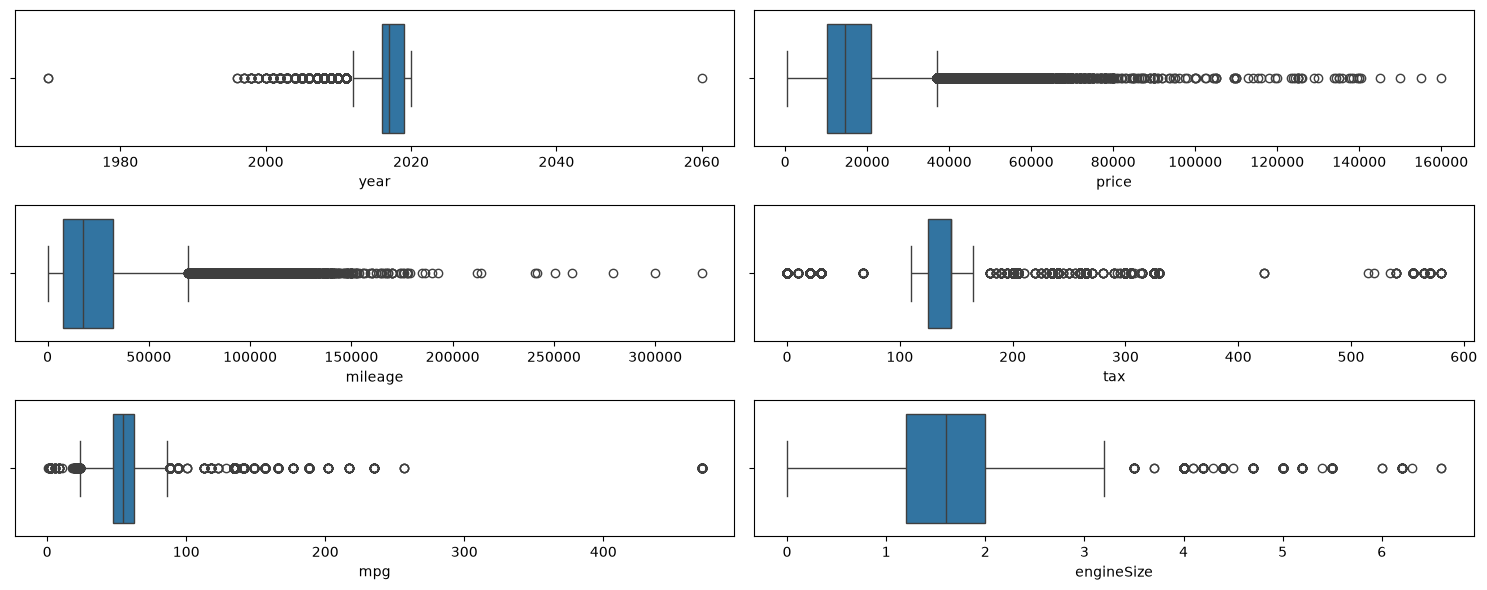

In [17]:
fig, ax = plt.subplots(3,2, figsize=(15,6))

i = 0
j = 0
for var in df[num]:
    sns.boxplot(df,x=var,ax=ax[i,j])
    if j==1:
        j=0
        i+=1
    else:
        j+=1

plt.tight_layout()
plt.show()

In [18]:
outlier_year=df[df['year']>2026]
print(outlier_year)
df=df.drop(outlier_year.index,axis=0)

         model  year  price transmission  mileage fuelType    tax   mpg  \
49544   Fiesta  2060   6495    Automatic    54807   Petrol  205.0  42.8   

       engineSize  Make  
49544         1.4  ford  


In [19]:
df[df['mpg']>400].head(8)             # i won't drop this outliers

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
95627,i3,2016,17100,Automatic,25269,Other,0.0,470.8,0.6,bmw
96214,i3,2017,19998,Automatic,41949,Hybrid,140.0,470.8,0.0,bmw
96370,i3,2017,19998,Automatic,41146,Hybrid,0.0,470.8,0.0,bmw
96372,i3,2017,21898,Automatic,10839,Hybrid,0.0,470.8,0.0,bmw
97397,i3,2017,19980,Automatic,26965,Hybrid,140.0,470.8,0.0,bmw
97882,i3,2016,19490,Automatic,8421,Hybrid,0.0,470.8,0.0,bmw
98800,i3,2016,16482,Automatic,43695,Hybrid,0.0,470.8,0.0,bmw
99151,i3,2015,14285,Automatic,65800,Hybrid,0.0,470.8,0.0,bmw


## Skewness

year  :  -2.0070793209921685
price  :  2.3051801758692494
mileage  :  1.7852223566785408
tax  :  -0.020128480613364676
mpg  :  8.988514291782144
engineSize  :  1.3147317326741037


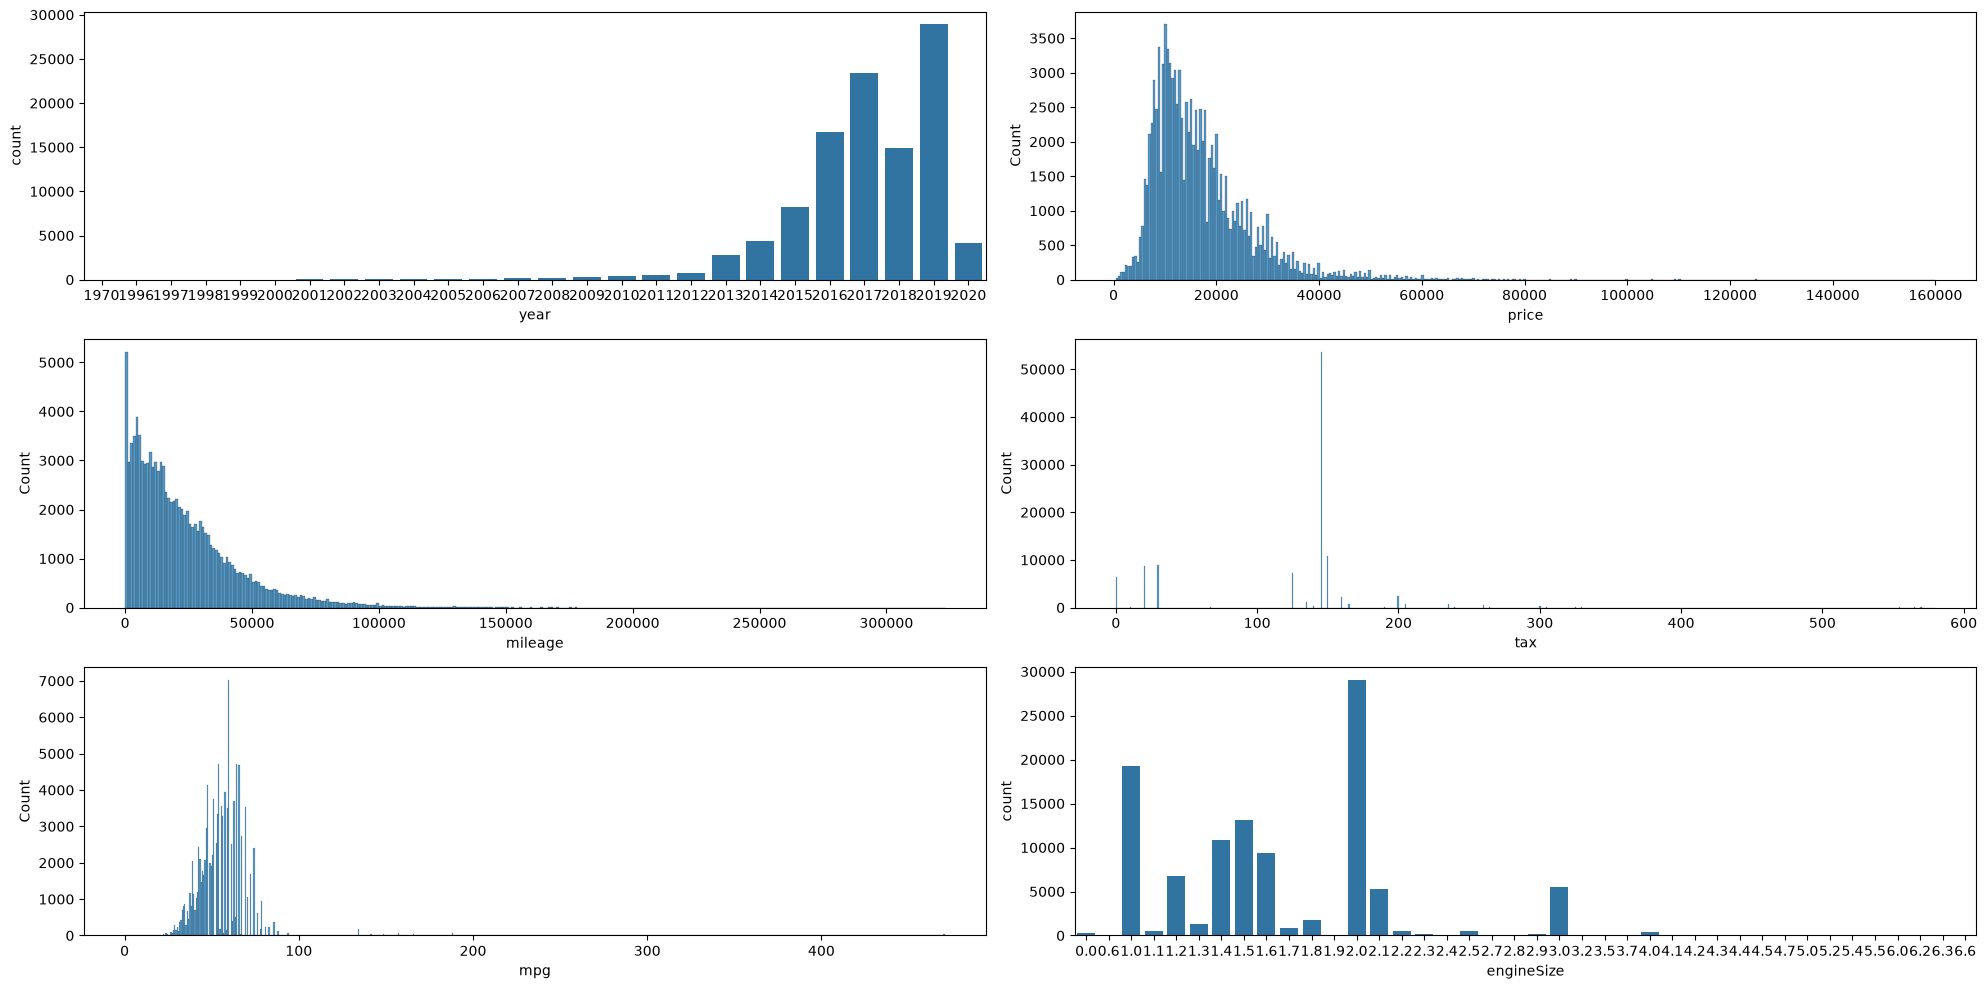

In [20]:
for col in num:
    print(col," : ",df[col].skew())

num_con=['price','mileage','tax','mpg']

fig, ax = plt.subplots(3,2, figsize=(20,10))

i = 0
j = 0
for var in df[num]:
    if var in num_con:
        sns.histplot(df[var],ax=ax[i,j])
    else:
        sns.countplot(df,x=var,ax=ax[i,j])
    if j==1:
        j=0
        i+=1
    else:
        j+=1

plt.tight_layout()
plt.show()

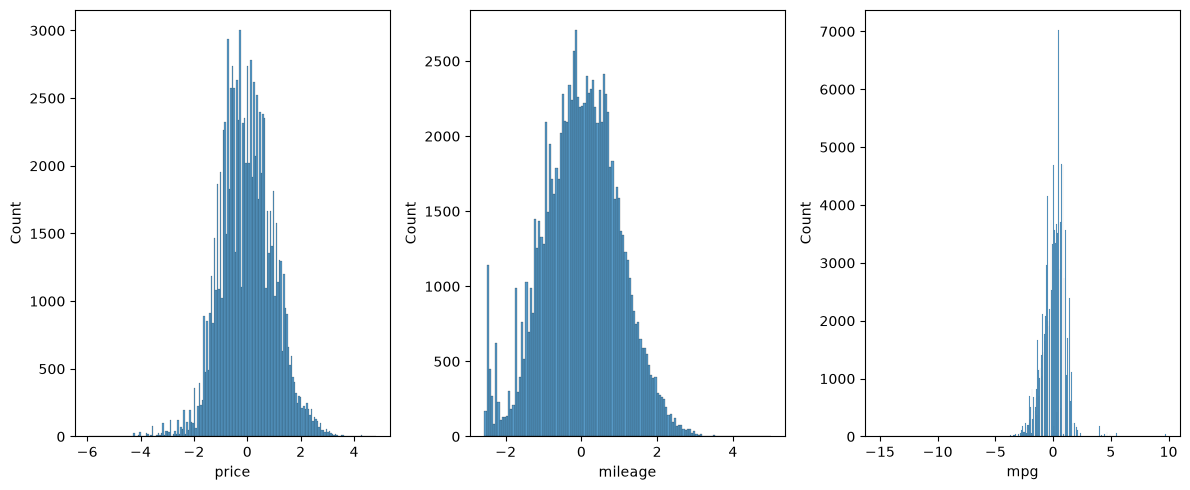

In [21]:
skewed=['price','mileage','mpg']
from sklearn.preprocessing import PowerTransformer

transformers = {}

fig, ax = plt.subplots(1,3, figsize=(12,5))
i=0

for col in skewed:
    tran=PowerTransformer()
    transformers[col] = tran
    
    df[[col]] = tran.fit_transform(df[[col]])
    sns.histplot(df[col],ax=ax[i])
    i+=1
    #
plt.tight_layout()


# Data Visualization

In [22]:
for col in cat:
    print(col," : ",df[col].unique())

model  :  <ArrowStringArray>
[      ' A1',       ' A6',       ' A4',       ' A3',       ' Q3',       ' Q5',
       ' A5',       ' S4',       ' Q2',       ' A7',
 ...
       ' X6', ' 8 Series',       ' Z4',       ' X7',       ' M5',       ' i8',
       ' M2',       ' M3',       ' M6',       ' Z3']
Length: 195, dtype: str
transmission  :  <ArrowStringArray>
['Manual', 'Automatic', 'Semi-Auto', 'Other']
Length: 4, dtype: str
fuelType  :  <ArrowStringArray>
['Petrol', 'Diesel', 'Hybrid', 'Other', 'Electric']
Length: 5, dtype: str
Make  :  <ArrowStringArray>
[    'audi',   'cclass',     'merc',    'focus',     'ford',   'hyundi',
    'skoda',   'toyota',       'vw', 'vauxhall',      'bmw']
Length: 11, dtype: str


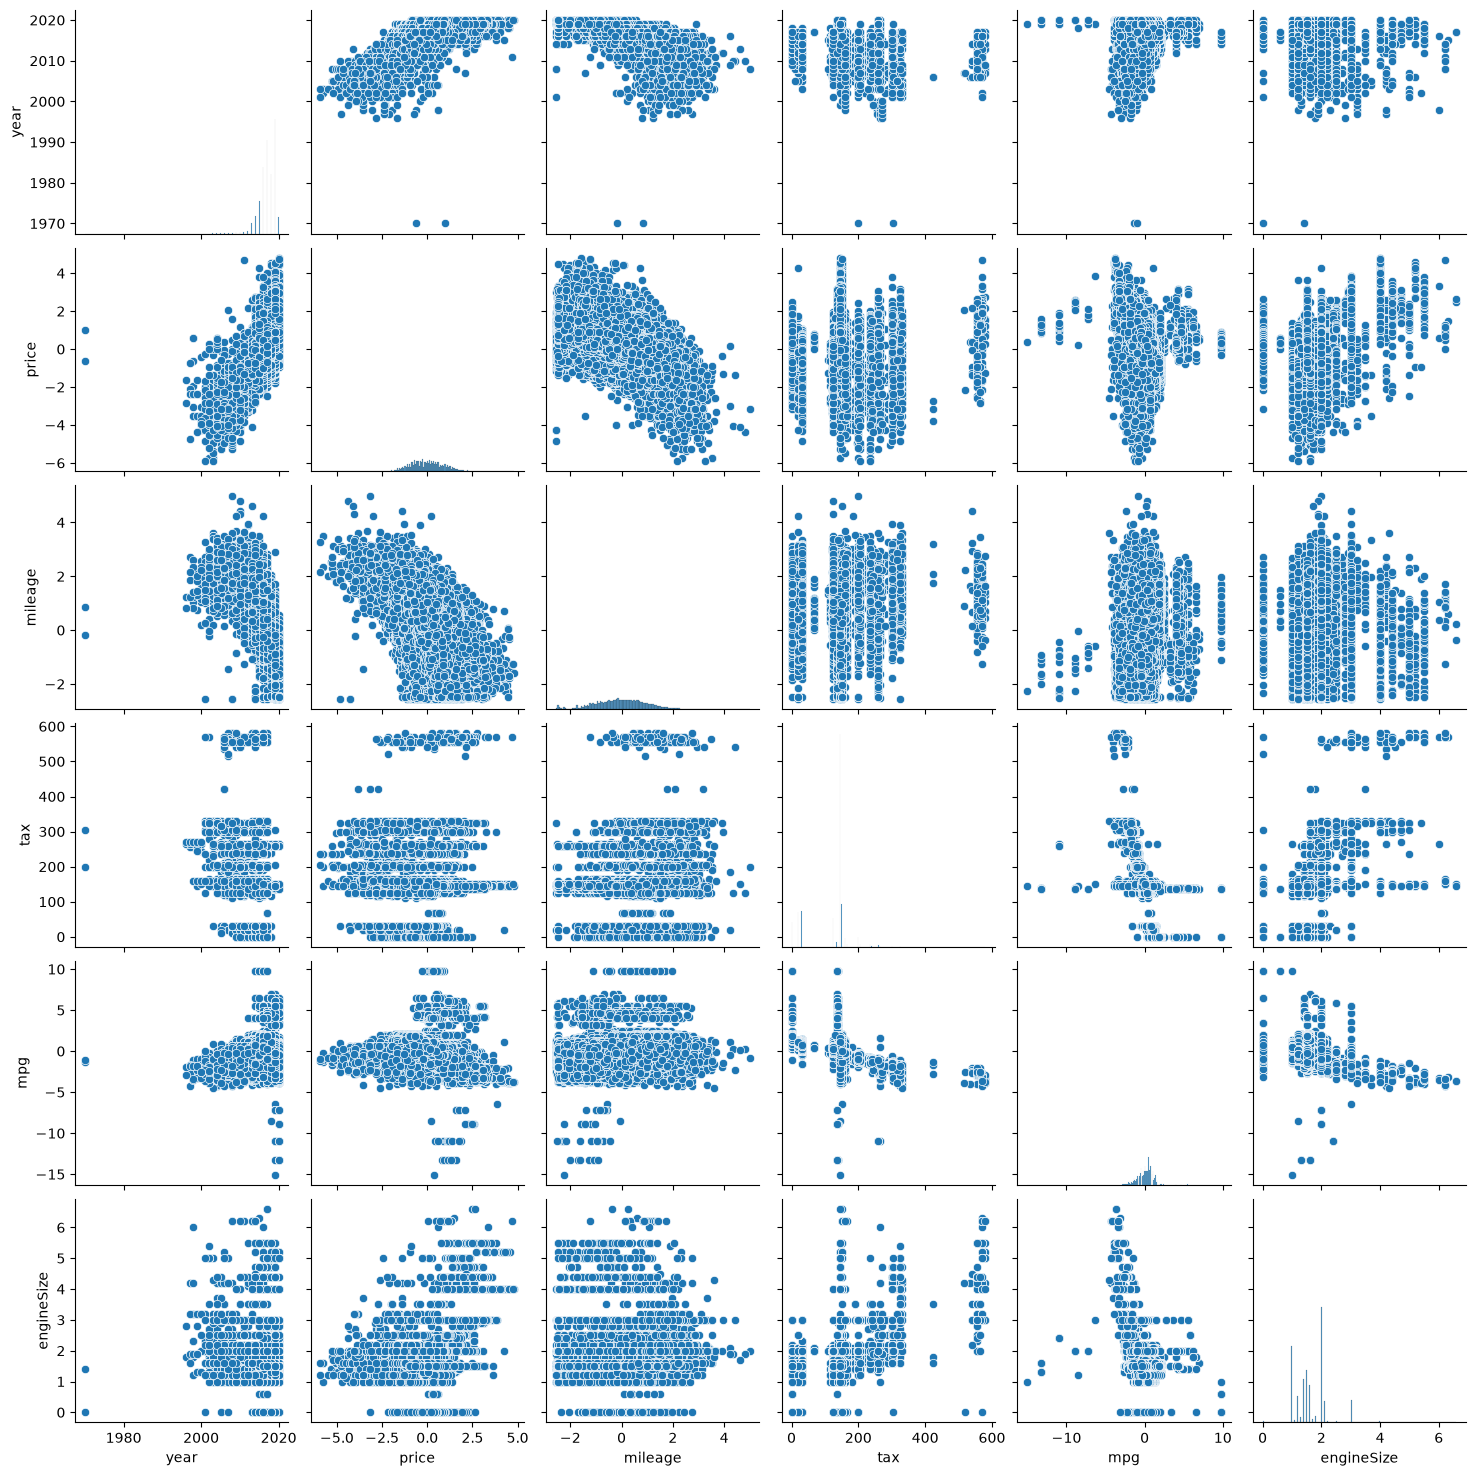

In [23]:
sns.pairplot(df[num])

<Axes: >

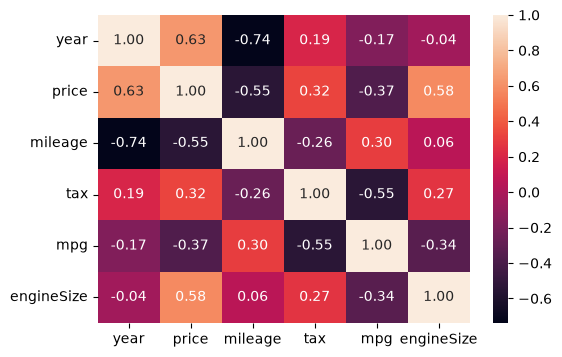

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(df[num].corr(),annot=True,fmt='.2f')

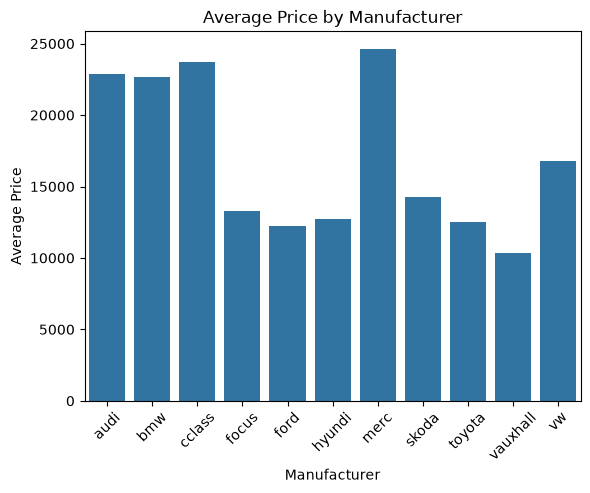

In [25]:
normal_price= transformers['price'].inverse_transform(df[['price']]).ravel()

temp = pd.DataFrame({
    'Make': df['Make'],
    'price': normal_price,
    'transmission':df['transmission'],
    'fuelType': df['fuelType']
})


avg_price= temp.groupby('Make',as_index=False)['price'].mean()

sns.barplot(avg_price,x='Make',y='price')
plt.xticks(rotation=45)
plt.xlabel('Manufacturer')
plt.ylabel('Average Price')
plt.title('Average Price by Manufacturer')
plt.show()


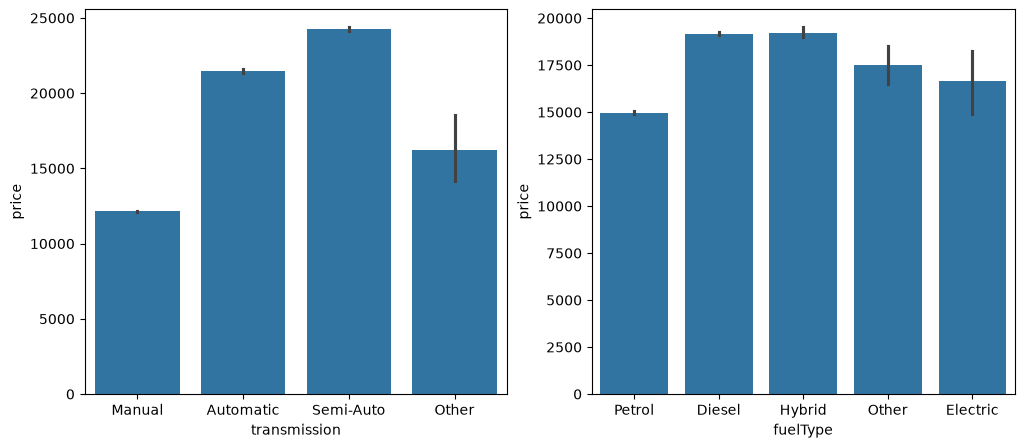

In [26]:
fig, ax= plt.subplots(1,2, figsize=(12,5))

i=0
for col in ['transmission','fuelType']:
    sns.barplot(temp,x=col,y='price',ax=ax[i])
    i+=1


Text(0.5, 1.0, 'Manifacturers')

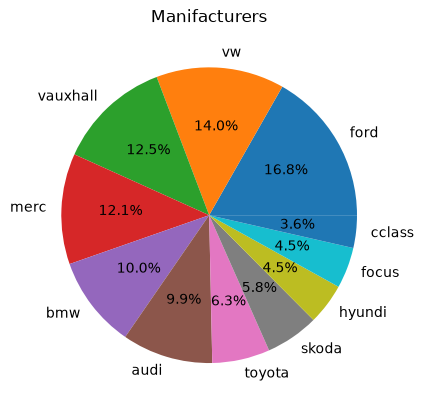

In [27]:
make_counts=df['Make'].value_counts()

plt.pie(make_counts,labels=make_counts.index,autopct='%1.1f%%')

plt.title("Manifacturers")

# Split The data

In [28]:
from sklearn.model_selection import train_test_split

X=df.drop('price',axis=1)
y=df['price']


X_train_val, X_test,y_train_val,y_test = train_test_split(X,y,test_size=0.15,random_state=42,shuffle=True)

X_train,X_val,y_train,y_val = train_test_split(X_train_val,y_train_val,random_state=42,test_size=0.1765)

print(f"Train size: {len(X_train)/len(X):.2%}")  # ~70%
print(f"Val size:   {len(X_val)/len(X):.2%}")    # ~15%
print(f"Test size:  {len(X_test)/len(X):.2%}")   # ~15%


X_train_org = X_train.copy()
X_val_org =X_val.copy()
X_test_org= X_test.copy()


y_train_org = y_train.copy()
y_val_org =y_val.copy()
y_test_org= y_test.copy()

Train size: 70.00%
Val size:   15.00%
Test size:  15.00%


## Data preprocessing

## Encoding

In [29]:
for col in cat:
    print(col," : ",df[col].unique())

model  :  <ArrowStringArray>
[      ' A1',       ' A6',       ' A4',       ' A3',       ' Q3',       ' Q5',
       ' A5',       ' S4',       ' Q2',       ' A7',
 ...
       ' X6', ' 8 Series',       ' Z4',       ' X7',       ' M5',       ' i8',
       ' M2',       ' M3',       ' M6',       ' Z3']
Length: 195, dtype: str
transmission  :  <ArrowStringArray>
['Manual', 'Automatic', 'Semi-Auto', 'Other']
Length: 4, dtype: str
fuelType  :  <ArrowStringArray>
['Petrol', 'Diesel', 'Hybrid', 'Other', 'Electric']
Length: 5, dtype: str
Make  :  <ArrowStringArray>
[    'audi',   'cclass',     'merc',    'focus',     'ford',   'hyundi',
    'skoda',   'toyota',       'vw', 'vauxhall',      'bmw']
Length: 11, dtype: str


model --> target encoding  / make,transmission,fuelType --> binary

In [30]:
import category_encoders as ce

encoder_tar= ce.TargetEncoder(cols=['model'])

X_train['model'] = encoder_tar.fit_transform(X_train['model'],y_train)

X_val['model'] = encoder_tar.transform(X_val['model'])
X_test['model'] = encoder_tar.transform(X_test['model'])

In [31]:
#from sklearn.preprocessing import OneHotEncoder
#
#encoder_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
#
#cat_cols = ['Make', 'transmission', 'fuelType']
#
#X_train_ohe = encoder_ohe.fit_transform(X_train[cat_cols])
#X_val_ohe = encoder_ohe.transform(X_val[cat_cols])
#X_test_ohe = encoder_ohe.transform(X_test[cat_cols])
#
#X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_ohe.get_feature_names_out(cat_cols), index=X_train.index)
#X_val_ohe = pd.DataFrame(X_val_ohe, columns=encoder_ohe.get_feature_names_out(cat_cols), index=X_val.index)
#X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_ohe.get_feature_names_out(cat_cols), index=X_test.index)
#
#X_train = pd.concat([X_train.drop(columns=cat_cols), X_train_ohe], axis=1)
#X_val = pd.concat([X_val.drop(columns=cat_cols), X_val_ohe], axis=1)
#X_test = pd.concat([X_test.drop(columns=cat_cols), X_test_ohe], axis=1)
#
#X_train


In [32]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
Encoder={}
for col in ['Make', 'transmission', 'fuelType']:
    Encoder[col]= LabelEncoder()
    X_train[col] = Encoder[col].fit_transform(X_train[col])
    X_val[col] = Encoder[col].transform(X_val[col])
    X_test[col] = Encoder[col].transform(X_test[col])

    print(Encoder[col].classes_)

X_train

['audi' 'bmw' 'cclass' 'focus' 'ford' 'hyundi' 'merc' 'skoda' 'toyota'
 'vauxhall' 'vw']
['Automatic' 'Manual' 'Other' 'Semi-Auto']
['Diesel' 'Electric' 'Hybrid' 'Other' 'Petrol']


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,Make
83737,-1.187805,2019,1,-1.275012,4,150.0,-0.899743,1.4,9
85659,-0.764222,2016,1,0.784685,4,20.0,0.754608,1.0,9
16286,1.196525,2019,3,-0.642582,4,145.0,-0.564901,2.0,6
71792,0.106406,2016,1,1.093051,0,20.0,0.957552,2.0,10
272,-0.133860,2019,1,-2.473002,4,145.0,-0.423735,1.0,0
...,...,...,...,...,...,...,...,...,...
103322,1.266722,2019,1,-1.059119,4,150.0,-0.967859,1.5,1
28606,-0.339121,2017,1,0.363114,0,145.0,0.754608,1.5,3
71161,0.106406,2017,3,0.098073,4,30.0,-0.040919,1.4,10
28585,-0.339121,2013,1,1.386156,0,30.0,-0.195120,1.6,3


In [33]:
#encoder_bin= ce.BinaryEncoder(cols=['Make','transmission','fuelType'])
#
#X_train = encoder_bin.fit_transform(X_train)
#
#X_val  = encoder_bin.transform(X_val)
#X_test = encoder_bin.transform(X_test)
#
#
#X_train


## Feature Scaling

In [34]:
from sklearn.preprocessing import RobustScaler
scaler= RobustScaler()

X_train = scaler.fit_transform(X_train)
X_train= pd.DataFrame(X_train,columns=X_val.columns,index=y_train.index)

X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

X_val = pd.DataFrame(X_val,columns=X_train.columns,index=y_val.index)
X_test = pd.DataFrame(X_test,columns=X_train.columns,index=y_test.index)

# Building Model

In [35]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
reg_results = {}

def evaluate_regressor(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    reg_results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
    print(f"--- {name} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    print()

In [36]:
y_train = transformers['price'].inverse_transform(y_train.to_numpy().reshape(-1,1))
y_val = transformers['price'].inverse_transform(y_val.to_numpy().reshape(-1,1))
y_test= transformers['price'].inverse_transform(y_test.to_numpy().reshape(-1,1))

y_train


array([[10698.],
       [ 8891.],
       [31495.],
       ...,
       [14290.],
       [ 5960.],
       [17995.]], shape=(74377, 1))

In [37]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_val)


evaluate_regressor('LinearRegression', y_val, y_pred)


--- LinearRegression ---
MAE:  2648.7222
MSE:  16843124.0560
RMSE: 4104.0375
R2:   0.8208



In [38]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

dt= DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_val)


evaluate_regressor('DecisionTree', y_val, y_pred)

--- DecisionTree ---
MAE:  1450.6073
MSE:  6626033.0895
RMSE: 2574.1082
R2:   0.9295



In [39]:
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_val)

evaluate_regressor('RandomForest',y_val,y_pred)

C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


--- RandomForest ---
MAE:  1164.3267
MSE:  3542357.7413
RMSE: 1882.1152
R2:   0.9623



In [40]:
gb= GradientBoostingRegressor(random_state=42)
gb.fit(X_train,y_train)

y_pred=gb.predict(X_val)

evaluate_regressor('GradientBoosting',y_val,y_pred)

C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_gb.py:691: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


--- GradientBoosting ---
MAE:  1711.0557
MSE:  6972452.0623
RMSE: 2640.5401
R2:   0.9258



In [41]:
from xgboost import XGBRegressor
xg= XGBRegressor()
xg.fit(X_train,y_train)
y_pred=xg.predict(X_val)

evaluate_regressor('XGBoost',y_val,y_pred)

--- XGBoost ---
MAE:  1247.2321
MSE:  3559400.0544
RMSE: 1886.6372
R2:   0.9621



In [42]:
reg_results_df = pd.DataFrame(reg_results).T.sort_values("R2", ascending=False)
display(reg_results_df.style.background_gradient(cmap="Greens", subset=["R2"]).format("{:.4f}"))


,MAE,MSE,RMSE,R2
RandomForest,1164.3267,3542357.7413,1882.1152,0.9623
XGBoost,1247.2321,3559400.0544,1886.6372,0.9621
DecisionTree,1450.6073,6626033.0895,2574.1082,0.9295
GradientBoosting,1711.0557,6972452.0623,2640.5401,0.9258
LinearRegression,2648.7222,16843124.0560,4104.0375,0.8208


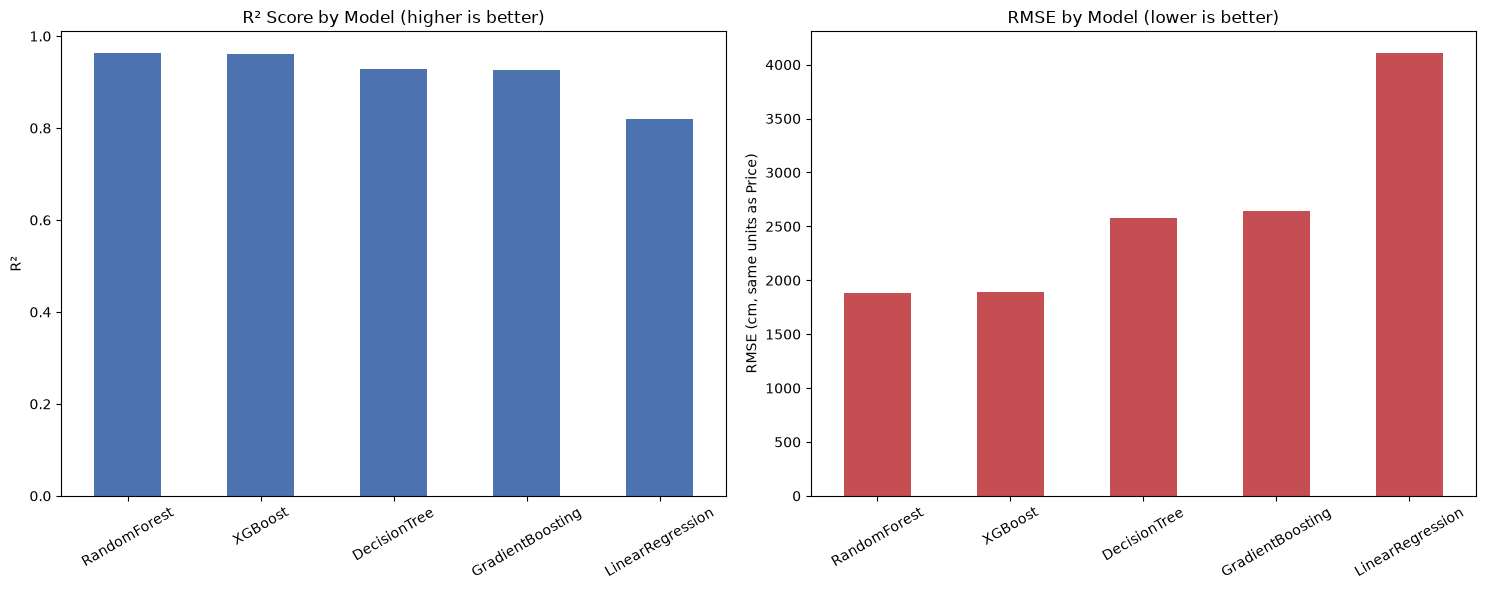

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

reg_results_df["R2"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("R² Score by Model (higher is better)")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=30)

reg_results_df["RMSE"].plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("RMSE by Model (lower is better)")
axes[1].set_ylabel("RMSE (cm, same units as Price)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Check Overfitting 

In [44]:
y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

print("Training:")
print(f"R²   : {train_r2:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAE  : {train_mae:.4f}")

print("\nValidation:")
print(f"R²   : {val_r2:.4f}")
print(f"RMSE : {val_rmse:.4f}")
print(f"MAE  : {val_mae:.4f}")

Training:
R²   : 0.9938
RMSE : 768.5657
MAE  : 442.9601

Validation:
R²   : 0.9623
RMSE : 1882.1152
MAE  : 1164.3267


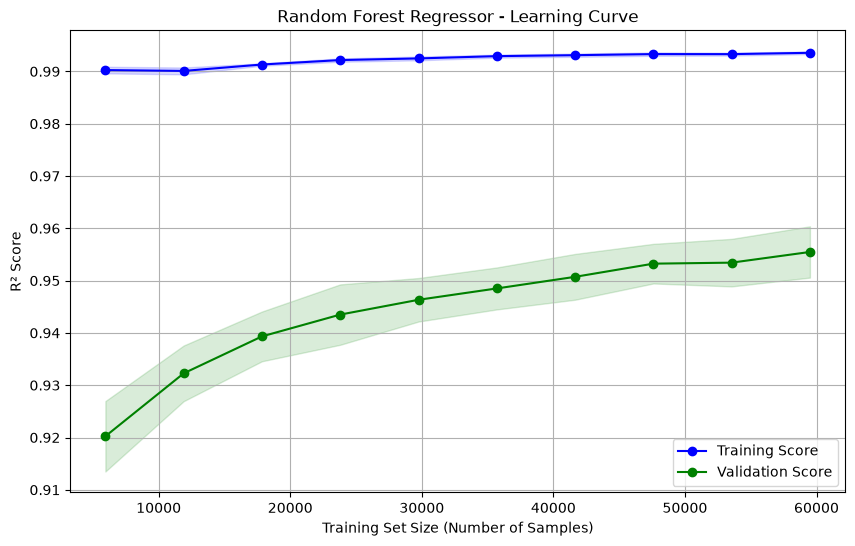

In [45]:

from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X_tr, y_tr, title="Learning Curve"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_tr,
        y=y_tr,
        train_sizes=np.linspace(0.1, 1.0, 10), # 10 steps from 10% to 100% data
        cv=5,                                  # Uses 5-fold CV internally
        scoring='r2',                          # Or 'neg_root_mean_squared_error'
        n_jobs=-1,
        random_state=42
    )

    # Calculate mean and standard deviation across folds
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)

    # 3. Plot the learning curves
    plt.figure(figsize=(10, 6))
    
    # Train Line
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

    # Validation Line
    plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation Score')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='green')

    plt.title(f"{title} - Learning Curve")
    plt.xlabel("Training Set Size (Number of Samples)")
    plt.ylabel("R² Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_learning_curve(rf, X_train, y_train, title="Random Forest Regressor")

In [46]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

# hyperparameter Tuning 

In [47]:
#from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
#rf_2= RandomForestRegressor(random_state=42,n_jobs=-1)
#params={
#    'n_estimators':[100,200,300],
#    'max_depth':[10,20,30],
#    'max_features':[1.0, 'sqrt', 'log2', 0.5, 0.7]
#}
#grid=GridSearchCV(
#    rf_2,
#    params,
#    cv=4,
#    n_jobs=-1,
#    scoring='r2'
#)
#grid.fit(X_train,y_train)
#
#print(grid.best_params_)
#print(grid.best_score_)
#
#{'max_depth': 20, 'max_features': 0.5, 'n_estimators': 300}
#0.9585560249470276


In [48]:
#from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
#rf_2= RandomForestRegressor(random_state=42)
#params={
#    'n_estimators':[100,300,350],
#    'max_depth':[10,15,20],
#    'max_features':[1.0, 'sqrt', 0.5],
#    'min_samples_split': [2, 5, 10],
#    'min_samples_leaf': [1, 2, 4, 5, 10]
#}
#Ran=RandomizedSearchCV(
#    rf_2,
#    params,
#    cv=5,
#    n_jobs=-1,
#    scoring='r2',
#    n_iter=50
#)
#Ran.fit(X_train,y_train)
#
#print(Ran.best_params_)
#print(Ran.best_score_)
#
#{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}
#0.9595755269475271


In [49]:
#from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
#rf_2= RandomForestRegressor(random_state=42)
#params={
#    'n_estimators':[250,300],
#    'max_depth':[12,20],
#    'max_features':['sqrt', 0.5],
#    'min_samples_split': [3, 5, 8],
#    
#}
#grid=GridSearchCV(
#    rf_2,
#    params,
#    cv=4,
#    n_jobs=-1,
#    scoring='r2'
#)
#grid.fit(X_train,y_train)
#
#{'max_depth': 12, 'max_features': 0.5, 'min_samples_split': 5, 'n_estimators': 300}
#0.9586249328071316



# Final Model

In [50]:
rf_2= RandomForestRegressor(random_state=42,max_depth=12,max_features=0.5,n_estimators=300,min_samples_split=5,min_samples_leaf=1)
rf_2.fit(X_train,y_train)
y_pred_val=rf_2.predict(X_val)

evaluate_regressor('RandomForest_2',y_val,y_pred_val)

C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


--- RandomForest_2 ---
MAE:  1295.0927
MSE:  3983003.7536
RMSE: 1995.7464
R2:   0.9576



### Final Evaluation

In [51]:
y_pred_test = rf_2.predict(X_test)

evaluate_regressor('RandomForest_2', y_test, y_pred_test)

--- RandomForest_2 ---
MAE:  1290.2510
MSE:  4307822.1926
RMSE: 2075.5294
R2:   0.9550



In [52]:
rf_2.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 12,
 'max_features': 0.5,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [53]:
y_train_pred = rf_2.predict(X_train)
y_val_pred = rf_2.predict(X_val)
y_test_pred=rf_2.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2= r2_score(y_test,y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Training:")
print(f"R²   : {train_r2:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAE  : {train_mae:.4f}")

print("\nValidation:")
print(f"R²   : {val_r2:.4f}")
print(f"RMSE : {val_rmse:.4f}")
print(f"MAE  : {val_mae:.4f}")

print("\nTesting:")
print(f"R²   : {test_r2:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAE  : {test_mae:.4f}")

Training:
R²   : 0.9668
RMSE : 1784.8164
MAE  : 1177.3222

Validation:
R²   : 0.9576
RMSE : 1995.7464
MAE  : 1295.0927

Testing:
R²   : 0.9550
RMSE : 2075.5294
MAE  : 1290.2510


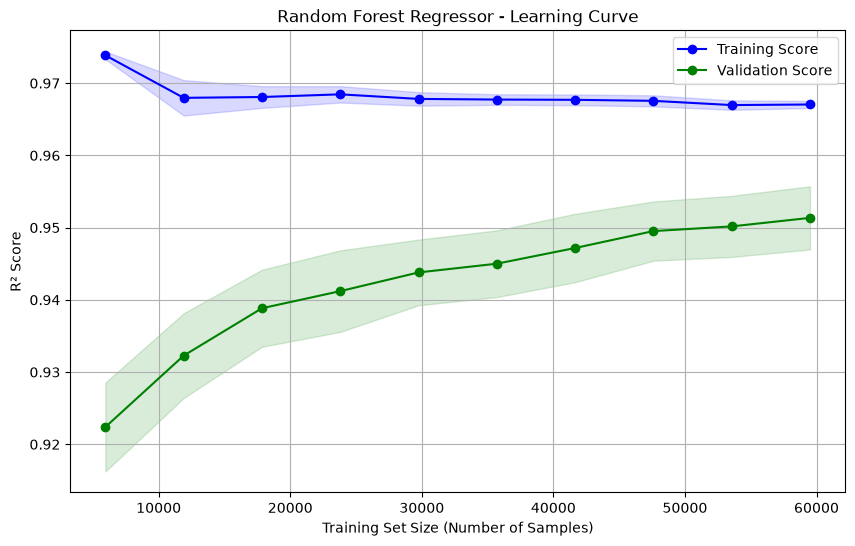

In [54]:

from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X_tr, y_tr, title="Learning Curve"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_tr,
        y=y_tr,
        train_sizes=np.linspace(0.1, 1.0, 10),                              # 10 steps from 10% to 100% data
        cv=5,                                                                  # Uses 5-fold CV internally
        scoring='r2',                              # 'r2'  or 'neg_root_mean_squared_error'
        n_jobs=-1,
        random_state=42
    )

    # Calculate mean and standard deviation across folds
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)

    # 3. Plot the learning curves
    plt.figure(figsize=(10, 6))
    
    # Train Line
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

    # Validation Line
    plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation Score')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='green')

    plt.title(f"{title} - Learning Curve")
    plt.xlabel("Training Set Size (Number of Samples)")
    plt.ylabel("R² Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_learning_curve(rf_2, X_train, y_train, title="Random Forest Regressor")

# Understand The Model

## Visualize the first tree

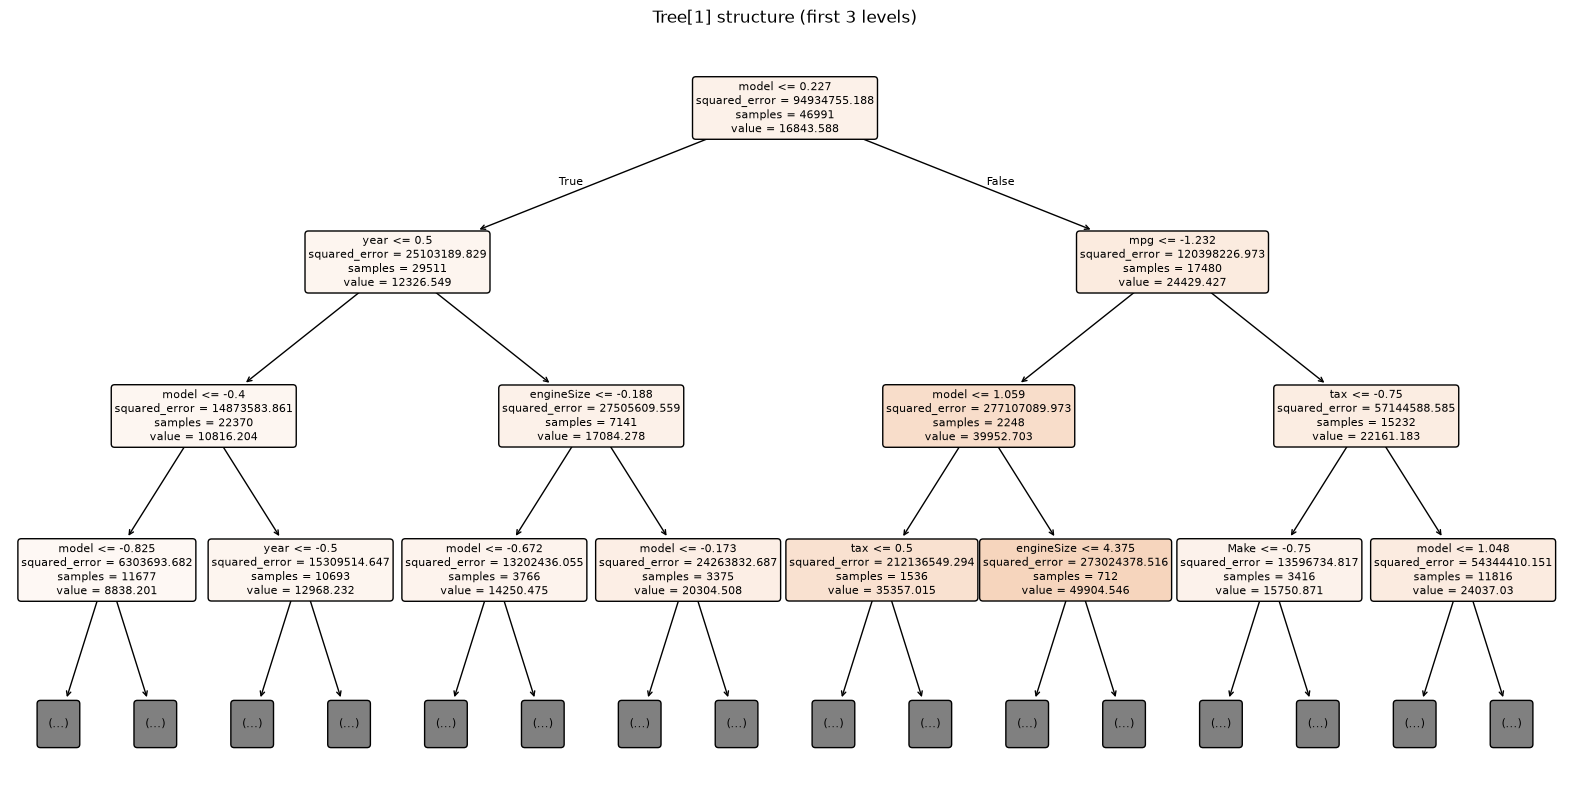

In [55]:
from sklearn.tree import plot_tree
# Visualize the actual learned one tree from RandomForest
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(rf_2.estimators_[0], feature_names=X_train.columns,
          filled=True, rounded=True, fontsize=8, ax=ax, max_depth=3)
ax.set_title("Tree[1] structure (first 3 levels)")
plt.show()

## View the Feature importance

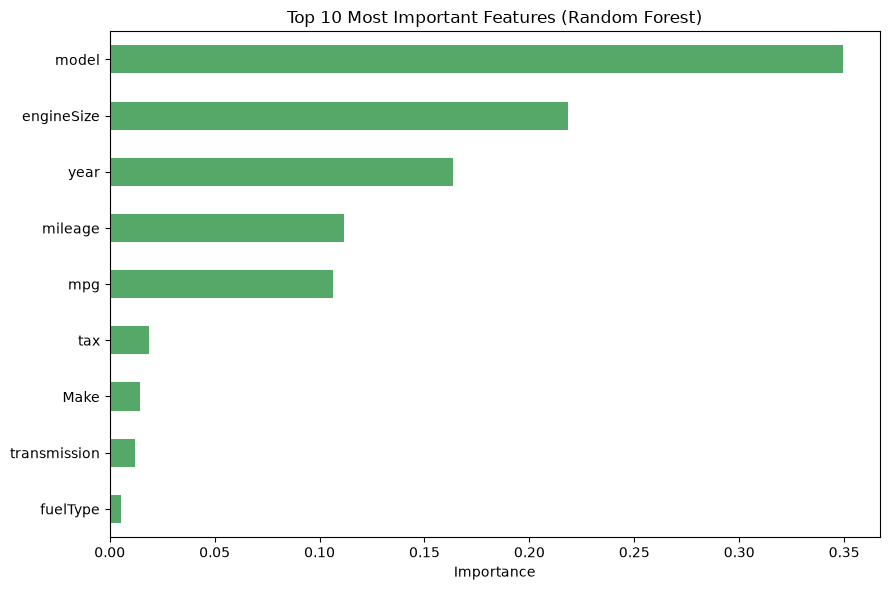

In [56]:
importances = pd.Series(rf_2.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
importances.sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Top 10 Most Important Features (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## Actual Vs Prediction 

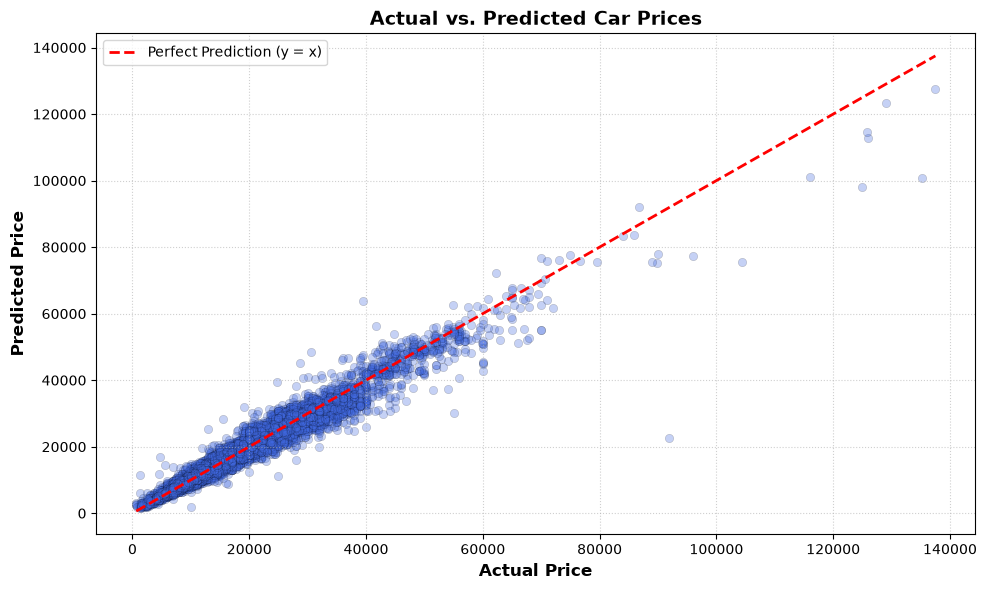

In [57]:

plt.figure(figsize=(10, 6))


plt.scatter(y_test, y_test_pred, alpha=0.3, color='royalblue', edgecolors='k', linewidth=0.3)

# 4. Add the Perfect Prediction Line (y = x)
max_val = max(max(y_test), max(y_test_pred))
min_val = min(min(y_test), min(y_test_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y = x)')


plt.xlabel('Actual Price', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Price', fontsize=12, fontweight='bold')
plt.title('Actual vs. Predicted Car Prices', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)


plt.tight_layout()
plt.show()

In [58]:
#n_estimators=100,
#    max_depth=12,           # 1. Stop trees from growing infinitely deep
#    min_samples_leaf=5,     # 2. Require at least 5 samples at leaf nodes
#    min_samples_split=10,   # 3. Require at least 10 samples to split an internal node
#    max_features='sqrt',    # 4. Limit features evaluated at each split
#    random_state=42


In [59]:
#y_pred = lr.predict(X_test.iloc[[1]])
#y_pred
#
#
#y_pred=transformers['price'].inverse_transform(y_pred.reshape(-1,1))
#y_pred
#
#
#print(transformers['price'].inverse_transform(df[['price']]))
#df['price']=transformers['price'].inverse_transform(df[['price']])
#
#
#df['price'].iloc[70484]
#
#
#te=y_test.iloc[1]
#te=transformers['price'].inverse_transform(te.reshape(-1,1))
#
#y_test
#
#te
#
#
#X_test.iloc[1].to_numpy().reshape(-1,1)


# Final Pipeline

In [60]:
X_train =X_train_org.copy()
X_val = X_val_org.copy()
X_test= X_test_org.copy()

y_train =y_train_org.copy()
y_val = y_val_org.copy()
y_test= y_test_org.copy()

y_train = transformers['price'].inverse_transform(y_train.to_numpy().reshape(-1,1))
y_val = transformers['price'].inverse_transform(y_val.to_numpy().reshape(-1,1))
y_test= transformers['price'].inverse_transform(y_test.to_numpy().reshape(-1,1))

y_train


array([[10698.],
       [ 8891.],
       [31495.],
       ...,
       [14290.],
       [ 5960.],
       [17995.]], shape=(74377, 1))

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

target_enc_cols = ['model']
ohe_cols  = ['Make','fuelType','transmission']
numeric_cols    = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

preprocessor = ColumnTransformer(transformers=[
    ('target_encoding',ce.TargetEncoder(cols=target_enc_cols),target_enc_cols),
    ('ohe_encoding', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ohe_cols),
    ('RobustScaler',RobustScaler(),numeric_cols)
],remainder='passthrough')

final_Pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('Model',RandomForestRegressor(random_state=42,oob_score=True,max_depth=12,max_features=1.0,n_estimators=300,min_samples_split=5,min_samples_leaf=1))
])

final_Pipeline.fit(X_train, y_train)


C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['model','year','transmission',...,'mpg','engineSize','Make']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('target_encoding', ...), ('ohe_encoding', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This sub

In [72]:
y_train_pred = final_Pipeline.predict(X_train)
y_val_pred = final_Pipeline.predict(X_val)
y_test_pred=final_Pipeline.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2= r2_score(y_test,y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Training:")
print(f"R²   : {train_r2:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAE  : {train_mae:.4f}")

print("\nValidation:")
print(f"R²   : {val_r2:.4f}")
print(f"RMSE : {val_rmse:.4f}")
print(f"MAE  : {val_mae:.4f}")

print("\nTesting:")
print(f"R²   : {test_r2:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAE  : {test_mae:.4f}")

Training:
R²   : 0.9683
RMSE : 1743.6243
MAE  : 1151.8261

Validation:
R²   : 0.9590
RMSE : 1962.4576
MAE  : 1282.3843

Testing:
R²   : 0.9567
RMSE : 2035.0051
MAE  : 1282.5421


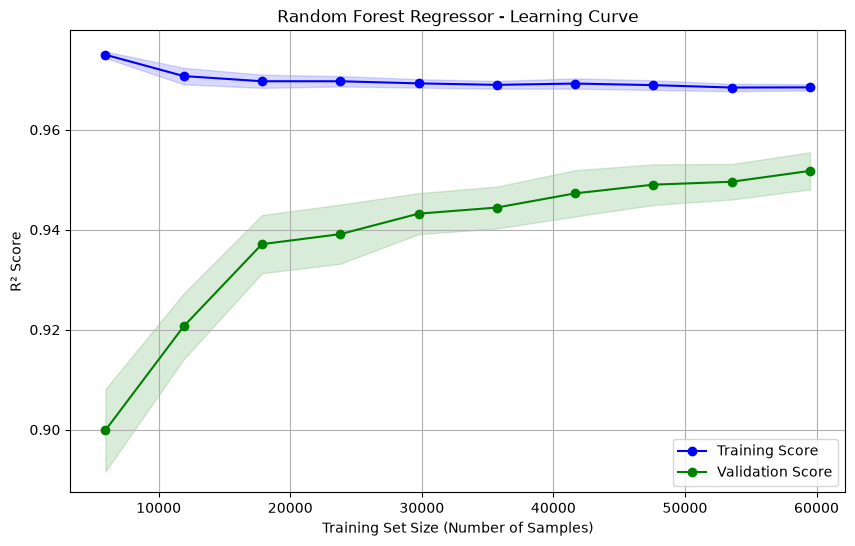

In [73]:

from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X_tr, y_tr, title="Learning Curve"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_tr,
        y=y_tr,
        train_sizes=np.linspace(0.1, 1.0, 10),                              # 10 steps from 10% to 100% data
        cv=5,                                                                  # Uses 5-fold CV internally
        scoring='r2',                              # 'r2'  or 'neg_root_mean_squared_error'
        n_jobs=-1,
        random_state=42
    )

    # Calculate mean and standard deviation across folds
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)

    # 3. Plot the learning curves
    plt.figure(figsize=(10, 6))
    
    # Train Line
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

    # Validation Line
    plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation Score')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='green')

    plt.title(f"{title} - Learning Curve")
    plt.xlabel("Training Set Size (Number of Samples)")
    plt.ylabel("R² Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_learning_curve(final_Pipeline, X_train, y_train, title="Random Forest Regressor")

# Save the Model

In [64]:
import joblib

joblib.dump(final_Pipeline,'model.pkl')

['model.pkl']

In [65]:
for cols in X_test.columns:
    print(cols,r"  \\\\  ",X_test[cols].unique())

model   \\\\   <ArrowStringArray>
[    ' Fiesta',       ' Golf',      ' Fabia',      ' Focus',    ' C Class',
     ' Touran',      ' Corsa',       ' Viva',         ' A7',      ' Mokka',
 ...
        ' Fox',         '180',         ' M6',         ' Z3',         '230',
 ' Caddy Life',         ' X7',     ' Vectra',         ' S8',    ' R Class']
Length: 178, dtype: str
year   \\\\   [2017 2019 2018 2015 2013 2016 2020 2003 2014 2012 2011 2007 2010 2008
 2009 1997 2005 2002 2006 1998 2004 2000 2001 1970]
transmission   \\\\   <ArrowStringArray>
['Manual', 'Semi-Auto', 'Automatic']
Length: 3, dtype: str
mileage   \\\\   [ 0.50066452 -1.24733498 -1.63003517 ... -1.17298227  0.22547964
 -1.03213286]
fuelType   \\\\   <ArrowStringArray>
['Diesel', 'Petrol', 'Hybrid', 'Other']
Length: 4, dtype: str
tax   \\\\   [145.   30.  150.  200.  205.  135.  235.  160.    0.  125.  260.   20.
 240.  165.  300.  140.  265.  250.   67.5 315.  325.  305.  565.  180.
 270.  115.  230.  120.  330.  580.   10.  1

In [66]:
X_test

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,Make
40233,Fiesta,2017,Manual,0.500665,Diesel,145.0,2.136402,1.5,ford
70484,Golf,2019,Semi-Auto,-1.247335,Petrol,145.0,-0.899743,1.5,vw
57100,Fabia,2019,Manual,-1.630035,Petrol,145.0,-0.121420,1.0,skoda
44633,Focus,2018,Manual,0.126974,Petrol,145.0,-1.097177,2.0,ford
22976,C Class,2019,Semi-Auto,-1.185811,Diesel,145.0,0.754608,2.0,merc
...,...,...,...,...,...,...,...,...,...
91577,Mokka X,2018,Manual,0.703682,Petrol,145.0,-1.335556,1.4,vauxhall
37324,Focus,2018,Manual,0.225480,Petrol,145.0,-1.097177,2.0,ford
6807,Q3,2019,Semi-Auto,-1.032133,Petrol,145.0,-1.443307,1.5,audi
38740,Fiesta,2017,Automatic,-0.348945,Petrol,145.0,0.297185,1.0,ford


In [67]:
y_test

array([[ 9499.],
       [22990.],
       [12790.],
       ...,
       [28950.],
       [11999.],
       [18381.]], shape=(15939, 1))